# Thermal Shimming Simulations

In [1]:
import femm
femm.openfemm("~/.wine/drive_c/femm42/bin/femm.exe")
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

mu_0 = 4*np.pi*10**-7

## Set Up Material Modelling, Model a Single Shim at Different Temperatures

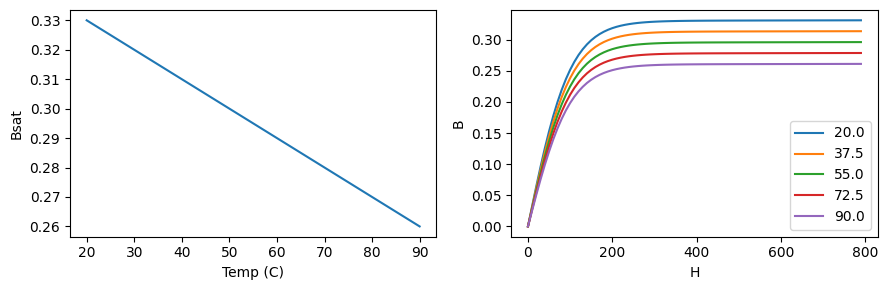

In [2]:
def get_ms(t):
    return .3500-0.001*t

# Create a function to simulate BH curves
def get_bh_curve(t):
    h0 = 100
    ms = get_ms(t)
    if np.isscalar(t):
        return lambda h : mu_0 * h + ms*np.tanh(h/h0)
    else:
        return np.array([lambda h, msat=msat : mu_0 * h + msat*np.tanh(h/h0) 
                         for msat in ms])

t = np.linspace(20,90,5)
h = np.arange(0,800,10)
chfigs, ax = plt.subplots(1,2, figsize=(9,3))
ax[0].plot(t, get_ms(t))
for bh_curve in get_bh_curve(t):
    ax[1].plot(h, bh_curve(h))
plt.legend(t)
ax[0].set_xlabel("Temp (C)")
ax[0].set_ylabel("Bsat")
ax[1].set_xlabel("H")
ax[1].set_ylabel("B")
plt.tight_layout()
plt.show()
# len([get_bh_curve(get_ms(t))[i](h) for i in range(len(t))])


def run_temp(temp):

    femm.openfemm("~/.wine/drive_c/femm42/bin/femm.exe")

    femm.newdocument(0)
    femm.mi_probdef(0,'millimeters','planar',1e-8,0,30)

    #Draw shim pieces
    pole_width = 50
    pole_thickness = 10
    pole_spacing = 35
    femm.mi_addmaterial('Air', 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0)

    bh = get_bh_curve(temp)
    npts = 20
    h = np.linspace(0,800,npts)
    femm.mi_addmaterial('Ft28_Tmp', 1, 1, 0, 0, 5.8, 0, 20)
    femm.mi_clearbhpoints('Ft28_Tmp')

    for i in range(npts):
        femm.mi_addbhpoint('Ft28_Tmp',bh(h[i]),h[i])

    #Shim pieces
    shim_width = 5
    shim_thickness = 10

    femm.mi_drawrectangle(-shim_thickness/2, -shim_width/2, shim_thickness/2, shim_width/2)

    femm.mi_addblocklabel(int(shim_thickness/2 + 3),0)
    femm.mi_selectlabel(int(shim_thickness/2 + 3),0)
    femm.mi_setblockprop('Air', 0, 1, '<None>', 0, 0, 0)
    femm.mi_clearselected()

    # femm.mi_setblockprop(matname, 0, 1, '<None>', 0, 0, 0)
    femm.mi_addblocklabel(0,0)
    femm.mi_selectlabel(0, 0)
    femm.mi_setblockprop('Ft28_Tmp', 0, 1, '<None>', 0, 0, 0)

    #Boundary Conditions
    femm.mi_makeABC(7, 100)

    Hc = 795774.715459477  # coercivity in A/m (example)

    for i in range(1, 8):
        mat_name = f"u{i}"
        femm.mi_modifymaterial(mat_name, 9, 0)  # 9 = lamination type, 0 = none
        femm.mi_modifymaterial(mat_name, 3, Hc)  # 3 = coercivity slot

    femm.mi_saveas("Z:\\coil" + str(temp) + ".fem")

    femm.mi_analyze()
    femm.mi_loadsolution()
    femm.mi_close()
    # femm.mi_zoom(-100,-100,100,100)

    # femm.mo_showdensityplot(1, 0, 0.51, 0.5, 'bmag')
    b = femm.mo_getb(20,0)[0]

    femm.closefemm()
    return b

In [40]:
run_temp(90)

-0.5054258260096568

In [23]:

temps = np.arange(20, 90, 5)
mags = np.zeros_like(temps, dtype=float)
for i in tqdm(range(len(temps))):
    mag = run_temp(temps[i])
    mags[i] = mag

  0%|          | 0/14 [00:00<?, ?it/s]

FEMM is already open


100%|██████████| 14/14 [01:03<00:00,  4.55s/it]


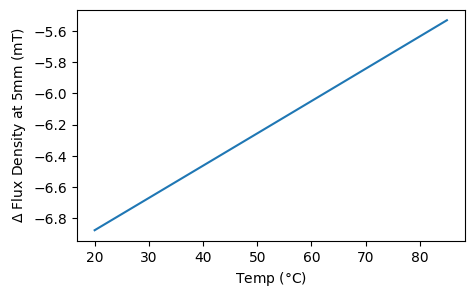

In [32]:
tempmagfig = plt.figure(figsize=(5,3))
plt.plot(temps, (mags+0.5)*1000)
plt.xlabel("Temp ($\degree $C)")
plt.ylabel("$\Delta$ Flux Density at 5mm (mT)")
plt.show()

## Single Shim Visualization

In [ ]:
# femm.newdocument(0)
femm.mi_probdef(0,'millimeters','planar',1e-8,0,30)

#Draw shim pieces
pole_width = 50
pole_thickness = 10
pole_spacing = 18
femm.mi_addmaterial('Air', 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0)
femm.mi_addmaterial('Nd42', 1.05, 1.05, 994529, 0, 0.667, 0)
# (’matname’, mu x, mu y, H c, J, Cduct, Lam d, Phi hmax, lam fill, LamType, Phi hx, Phi hy, nstr, dwire)

temp = 25
bh = get_bh_curve(temp)
npts = 20
h = np.linspace(0,10,npts)
femm.mi_addmaterial('Ft28_Tmp', 3000, 3000, 0, 0, 5.8, 0, 20)
femm.mi_clearbhpoints('Ft28_Tmp')

for i in range(npts):
    femm.mi_addbhpoint('Ft28_Tmp',bh(h[i]),h[i])

femm.mi_addblocklabel(0,0)
femm.mi_selectlabel(0,0)
femm.mi_setblockprop('Air', 0, 1, '<None>', 0, 0, 0)

#Pole pieces
femm.mi_drawrectangle(-pole_width/2, pole_spacing+pole_thickness, pole_width/2, pole_spacing)
femm.mi_drawrectangle(-pole_width/2, -pole_spacing-pole_thickness, pole_width/2, -pole_spacing)
femm.mi_addblocklabel(0,pole_spacing+pole_thickness/2)
femm.mi_selectlabel(0,pole_spacing+pole_thickness/2)
femm.mi_setblockprop('Nd42', 0, 1.5, '<None>', 90, 0, 0)
femm.mi_addblocklabel(0,-pole_spacing-pole_thickness/2)
femm.mi_selectlabel(0,-pole_spacing-pole_thickness/2)
femm.mi_setblockprop('Nd42', 0, 1.5, '<None>', 90, 0, 0)

#Shim pieces
nshims = 0
shim_gap = 2
shim_thickness = 2
shim_spacing = 14
for i in range(nshims):
    startx = -pole_width/2+pole_width/nshims*i+shim_gap/2
    endx = -pole_width/2+pole_width/nshims*(i+1)-shim_gap/2
    femm.mi_drawrectangle(startx, shim_spacing+shim_thickness, endx, shim_spacing)
    femm.mi_drawrectangle(startx, -shim_spacing-shim_thickness, endx, -shim_spacing)
    femm.mi_addblocklabel((startx+endx)/2,shim_spacing+shim_thickness/2)
    femm.mi_selectlabel((startx+endx)/2,shim_spacing+shim_thickness/2)
    
    # matname = "St1018_" +str(mu[i])
    # femm.mi_addmaterial(matname, mu[i], mu[i], 0, 0, 5.8, 0, 20)
    femm.mi_setblockprop('Ft28_Tmp', 0, 1, '<None>', 0, 0, 0)
    femm.mi_addblocklabel((startx+endx)/2,-shim_spacing-shim_thickness/2)
    femm.mi_selectlabel((startx+endx)/2,-shim_spacing-shim_thickness/2)
    femm.mi_setblockprop('Ft28_Tmp', 0, 1, '<None>', 0, 0, 0)

#Boundary Conditions
femm.mi_makeABC()
# femm.mi_zoom(-pole_width/2-10,-pole_thickness-pole_spacing-10,pole_width/2+10,pole_thickness+pole_spacing+10)

femm.mi_saveas('shim.fem')

femm.mi_analyze()
femm.mi_loadsolution()

NameError: name 'ifile' is not defined

## Design an Axisymmetric Shim Array

In [77]:
femm.openfemm("~/.wine/drive_c/femm42/bin/femm.exe")
femm.newdocument(0)
femm.mi_probdef(0,'millimeters','axi',1e-8,0,30)

#Draw shim pieces
pole_width = 50
pole_thickness = 10
pole_spacing = 20/2
femm.mi_addmaterial('Air', 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0)
femm.mi_addmaterial('Nd42', 1.05, 1.05, 994529, 0, 0.667, 0)
femm.mi_addmaterial('St1018_RmTmp', 529, 529, 0, 0, 5.8, 0, 20)

#Pole pieces
femm.mi_drawrectangle(0, pole_spacing+pole_thickness, pole_width/2, pole_spacing)
femm.mi_drawrectangle(0, -pole_spacing-pole_thickness, pole_width/2, -pole_spacing)
femm.mi_addblocklabel(5,pole_spacing+pole_thickness/2)
femm.mi_selectlabel(5,pole_spacing+pole_thickness/2)
femm.mi_setblockprop('Nd42', 0, 1, '<None>', 90, 0, 0)
femm.mi_addblocklabel(5,-pole_spacing-pole_thickness/2)
femm.mi_selectlabel(5,-pole_spacing-pole_thickness/2)
femm.mi_setblockprop('Nd42', 0, 1, '<None>', 90, 0, 0)

#Values for mu
ntemps = [20.0,20.0,20.0]
# ntemps = [20.1,20.0,20.0]
#Shim pieces
shim_gap = 2
shim_thickness = 4
shim_spacing = 5

femm.mi_drawrectangle(0, shim_spacing+shim_thickness, 17.653/2, shim_spacing)
femm.mi_drawrectangle(0, -shim_spacing-shim_thickness, 17.653/2, -shim_spacing)
femm.mi_drawrectangle(18.898/2, shim_spacing+shim_thickness, 36.83/2, shim_spacing)
femm.mi_drawrectangle(18.898/2, -shim_spacing-shim_thickness, 36.83/2, -shim_spacing)
femm.mi_drawrectangle(37.973/2, shim_spacing+shim_thickness, 55.88/2, shim_spacing)
femm.mi_drawrectangle(37.973/2, -shim_spacing-shim_thickness, 55.88/2, -shim_spacing)


for i in range(len(ntemps)):
    print(i)
    matname = "Ft_" + str(i)
    bh = get_bh_curve(ntemps[i])
    npts = 40
    h = np.linspace(0,1600,npts)
    femm.mi_addmaterial(matname, 1, 1, 0, 0, 5.8, 0, 20)
    femm.mi_clearbhpoints(matname)

    for j in range(npts):
        femm.mi_addbhpoint(matname,bh(h[j]),h[j])

    label_coords = [1.0, 13.0, 21.1]
    femm.mi_addblocklabel(label_coords[i],shim_spacing+shim_thickness/2)
    femm.mi_addblocklabel(label_coords[i],-shim_spacing-shim_thickness/2)
    femm.mi_selectlabel(label_coords[i],shim_spacing+shim_thickness/2)
    femm.mi_selectlabel(label_coords[i],-shim_spacing-shim_thickness/2)
    femm.mi_setblockprop(matname, 0, 1, '<None>', 0, 0, 0)
    femm.mi_clearselected()

#Boundary Conditions
femm.mi_makeABC()

femm.mi_addblocklabel(5,0)
femm.mi_selectlabel(0,0)
femm.mi_setblockprop('Air', 0, 1, '<None>', 0, 0, 0)

femm.mi_saveas("Z:\\coil" + ".fem")

femm.mi_analyze()
femm.mi_loadsolution()
femm.mi_close()
# femm.mi_zoom(-100,-100,100,100)

femm.mo_showdensityplot(1, 0, 0.35, 0.28, 'bmag')

fields = []
for n in range(20):
    fields.append(femm.mo_getb(n,0)[1])

femm.mo_zoom(-pole_width/2-10,-pole_thickness-pole_spacing-10,pole_width/2+10,pole_thickness+pole_spacing+10)

FEMM is already open
0
1
2


In [71]:
fields_150 = np.array(fields)

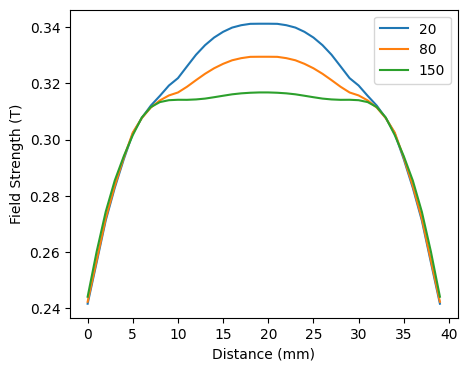

In [75]:
smagshimfig = plt.figure(figsize=(5,4))
plt.plot(np.concatenate((np.flip(fields_roomtemp), fields_roomtemp)))
plt.plot(np.concatenate((np.flip(fields_80), fields_80)))
plt.plot(np.concatenate((np.flip(fields_150), fields_150)))
plt.legend(["20", "80", "150"])
plt.xlabel("Distance (mm)")
plt.ylabel("Field Strength (T)")
plt.show()

## Design a 96 Well Plate Type Shim

In [3]:

#Simulate without shims

femm.openfemm("~/.wine/drive_c/femm42/bin/femm.exe")
femm.newdocument(0)
femm.mi_probdef(0,'millimeters','planar',1e-8,0,30)

#Draw shim pieces
pole_width = 150
pole_thickness = 30
pole_spacing = 30
femm.mi_addmaterial('Air', 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0)
femm.mi_addmaterial('Nd42', 1.05, 1.05, 994529, 0, 0.667, 0)
femm.mi_addmaterial('St1018_RmTmp', 529, 529, 0, 0, 5.8, 0, 20)

#Pole pieces - the top pole piece is canted to produce a field gradient
shim_pos = [-22.5, -7.5, 7.5, 22.5]

femm.mi_drawrectangle(-pole_width/2, pole_spacing+pole_thickness, pole_width/2, pole_spacing)
femm.mi_drawrectangle(-pole_width/2, -pole_spacing-pole_thickness, pole_width/2, -pole_spacing)
femm.mi_addblocklabel(5,pole_spacing+pole_thickness/2)
femm.mi_selectlabel(5,pole_spacing+pole_thickness/2)
femm.mi_setblockprop('Nd42', 0, 1, '<None>', 90, 0, 0)
femm.mi_addblocklabel(5,-pole_spacing-pole_thickness/2)
femm.mi_selectlabel(5,-pole_spacing-pole_thickness/2)
femm.mi_setblockprop('Nd42', 0, 1, '<None>', 90, 0, 0)
femm.mi_clearselected()

femm.mi_addblocklabel(5,0)
femm.mi_selectlabel(5,0)
femm.mi_setblockprop('Air', 0, 1, '<None>', 0, 0, 0)
femm.mi_clearselected()

#Boundary Conditions
femm.mi_makeABC()

femm.mi_saveas("Z:\\coil" + ".fem")

femm.mi_analyze()
femm.mi_loadsolution()
femm.mi_close()
# femm.mi_zoom(-100,-100,100,100)

femm.mo_showdensityplot(1, 0, 0.4, 0.15, 'bmag')

fields_noshims = []
for n in range(len(shim_pos)):
    fields_noshims.append(femm.mo_getb(shim_pos[n],0)[1])

print(fields_noshims)
femm.mo_zoom(-pole_width/2-10,-pole_thickness-pole_spacing-10,pole_width/2+10,pole_thickness+pole_spacing+10)

# Simulate with roomtemp shims

# femm.openfemm("~/.wine/drive_c/femm42/bin/femm.exe")
femm.newdocument(0)
femm.mi_probdef(0,'millimeters','planar',1e-8,0,30)

#Draw shim pieces
pole_width = 150
pole_thickness = 30
pole_spacing = 30
femm.mi_addmaterial('Air', 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0)
femm.mi_addmaterial('Nd42', 1.05, 1.05, 994529, 0, 0.667, 0)

#Pole pieces - the top pole piece is canted to produce a field gradient
cant = 5 #degrees

femm.mi_drawrectangle(-pole_width/2, pole_spacing+pole_thickness, pole_width/2, pole_spacing)
femm.mi_drawrectangle(-pole_width/2, -pole_spacing-pole_thickness, pole_width/2, -pole_spacing)
femm.mi_addblocklabel(5,pole_spacing+pole_thickness/2)
femm.mi_selectlabel(5,pole_spacing+pole_thickness/2)
femm.mi_setblockprop('Nd42', 0, 1, '<None>', 90, 0, 0)
femm.mi_addblocklabel(5,-pole_spacing-pole_thickness/2)
femm.mi_selectlabel(5,-pole_spacing-pole_thickness/2)
femm.mi_setblockprop('Nd42', 0, 1, '<None>', 90, 0, 0)

#Values for mu
ntemps = [20.0,20.0,20.0, 20.0]
#Shim pieces
shim_gap = 2
shim_thickness = 4
shim_spacing = 4
shim_width = 10
shim_pos = [-22.5, -7.5, 7.5, 22.5]

for i in range(len(shim_pos)):
    femm.mi_drawrectangle(shim_pos[i]-shim_width/2, -shim_spacing-shim_thickness, shim_pos[i]+shim_width/2, -shim_spacing)
    matname = "Ft_" + str(i)
    bh = get_bh_curve(ntemps[i])
    npts = 40
    h = np.linspace(0,1600,npts)
    femm.mi_addmaterial(matname, 1, 1, 0, 0, 5.8, 0, 20)
    femm.mi_clearbhpoints(matname)

    for j in range(npts):
        femm.mi_addbhpoint(matname,bh(h[j]),h[j])

    femm.mi_addblocklabel(shim_pos[i],-shim_spacing-shim_thickness/2)
    femm.mi_selectlabel(shim_pos[i],-shim_spacing-shim_thickness/2)
    femm.mi_setblockprop(matname, 0, 1, '<None>', 0, 0, 0)
    femm.mi_clearselected()

femm.mi_addblocklabel(5,0)
femm.mi_selectlabel(5,0)
femm.mi_setblockprop('Air', 0, 1, '<None>', 0, 0, 0)
femm.mi_clearselected()

#Boundary Conditions
femm.mi_makeABC()

femm.mi_saveas("Z:\\coil" + ".fem")

femm.mi_analyze()
femm.mi_loadsolution()
femm.mi_close()
# femm.mi_zoom(-100,-100,100,100)

# femm.mo_showdensityplot(1, 0, 0.2, 0.05, 'bmag')

fields_roomtemp = []
for n in range(len(shim_pos)):
    fields_roomtemp.append(femm.mo_getb(shim_pos[n],0)[1])

print(fields_roomtemp)
femm.mo_zoom(-pole_width/2-10,-pole_thickness-pole_spacing-10,pole_width/2+10,pole_thickness+pole_spacing+10)

# Simulate with working shims

# femm.openfemm("~/.wine/drive_c/femm42/bin/femm.exe")
femm.newdocument(0)
femm.mi_probdef(0,'millimeters','planar',1e-8,0,30)

#Draw shim pieces
pole_width = 150
pole_thickness = 30
pole_spacing = 30
femm.mi_addmaterial('Air', 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0)
femm.mi_addmaterial('Nd42', 1.05, 1.05, 994529, 0, 0.667, 0)
femm.mi_addmaterial('St1018_RmTmp', 529, 529, 0, 0, 5.8, 0, 20)

#Pole pieces - the top pole piece is canted to produce a field gradient
cant = 5 #degrees

femm.mi_drawrectangle(-pole_width/2, pole_spacing+pole_thickness, pole_width/2, pole_spacing)
femm.mi_drawrectangle(-pole_width/2, -pole_spacing-pole_thickness, pole_width/2, -pole_spacing)
femm.mi_addblocklabel(5,pole_spacing+pole_thickness/2)
femm.mi_selectlabel(5,pole_spacing+pole_thickness/2)
femm.mi_setblockprop('Nd42', 0, 1, '<None>', 90, 0, 0)
femm.mi_addblocklabel(5,-pole_spacing-pole_thickness/2)
femm.mi_selectlabel(5,-pole_spacing-pole_thickness/2)
femm.mi_setblockprop('Nd42', 0, 1, '<None>', 90, 0, 0)

#Values for mu
ntemps = [78.0,20.0,20.0, 78.0]
#Shim pieces
shim_gap = 2
shim_thickness = 4
shim_spacing = 4
shim_width = 10
shim_pos = [-22.5, -7.5, 7.5, 22.5]

for i in range(len(shim_pos)):
    femm.mi_drawrectangle(shim_pos[i]-shim_width/2, -shim_spacing-shim_thickness, shim_pos[i]+shim_width/2, -shim_spacing)
    matname = "Ft_" + str(i)
    bh = get_bh_curve(ntemps[i])
    npts = 40
    h = np.linspace(0,1600,npts)
    femm.mi_addmaterial(matname, 1, 1, 0, 0, 5.8, 0, 20)
    femm.mi_clearbhpoints(matname)

    for j in range(npts):
        femm.mi_addbhpoint(matname,bh(h[j]),h[j])

    femm.mi_addblocklabel(shim_pos[i],-shim_spacing-shim_thickness/2)
    femm.mi_selectlabel(shim_pos[i],-shim_spacing-shim_thickness/2)
    femm.mi_setblockprop(matname, 0, 1, '<None>', 0, 0, 0)
    femm.mi_clearselected()

femm.mi_addblocklabel(5,0)
femm.mi_selectlabel(5,0)
femm.mi_setblockprop('Air', 0, 1, '<None>', 0, 0, 0)
femm.mi_clearselected()

#Boundary Conditions
femm.mi_makeABC()

femm.mi_saveas("Z:\\coil" + ".fem")

femm.mi_analyze()
femm.mi_loadsolution()
femm.mi_close()
# femm.mi_zoom(-100,-100,100,100)

femm.mo_showdensityplot(1, 0, 0.4, 0.15, 'bmag')

fields_shims = []
for n in range(len(shim_pos)):
    fields_shims.append(femm.mo_getb(shim_pos[n],0)[1])

print(fields_shims)
femm.mo_zoom(-pole_width/2-10,-pole_thickness-pole_spacing-10,pole_width/2+10,pole_thickness+pole_spacing+10)

FEMM is already open
[0.2353605026986241, 0.2362545932260011, 0.236254595269099, 0.2353671863064297]
[0.2574390746443178, 0.2532074857272051, 0.2530975977162114, 0.2573765241945348]
[0.2543495152774704, 0.2544403863418055, 0.2543428708329739, 0.2542728200128618]


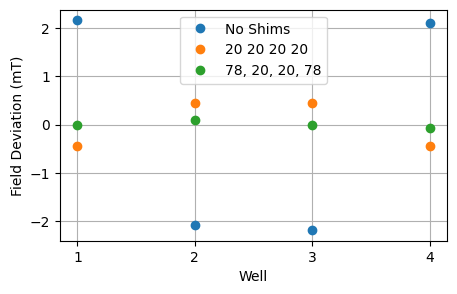

In [71]:
# 96WP Shim Figure
plt.figure(figsize=(5,3))
x = np.arange(1,5)
plt.plot(x, (np.array(fields_roomtemp)-np.mean(fields_roomtemp))*1000,'o')
plt.plot(x, (np.array(fields_noshims)-np.mean(fields_noshims))*1000,'o')
plt.plot(x, (np.array(fields_shims)-np.mean(fields_shims))*1000,'o')
plt.xticks([1,2,3,4])
plt.xlabel("Well")
plt.ylabel("Field Deviation (mT)")
plt.grid()
plt.legend(["No Shims", "20 20 20 20", "78, 20, 20, 78"])
plt.show()

In [37]:
femm.mo_showdensityplot(1, 0, 0.4, 0.15, 'bmag')